# Crystallizer: a crystal structure from the diffusion density

This notebook shows how to use the [`Crystallizer`][gemdat.crystallizer.Crystallizer] to
reconstruct a symmetry-fitted crystal structure (and a CIF file) from the occupancy density
of a molecular dynamics trajectory.

The pipeline is:

1. Load a trajectory and identify the diffusing species.
2. Turn its positions into an occupancy **density** volume.
3. Segment the density into candidate **sites** with partial occupancies.
4. Combine the sites with the time-averaged host framework and fit the highest space group.

Here we use the same Na&#8323;(Sb/W)S&#8324; run as the
[shape-analysis tutorial](../tutorials/gemdat_basic_analysis.ipynb): 46 sodium ions
diffusing through an Sb/W&ndash;S framework, simulated at 500&nbsp;K for 25&nbsp;000 frames.
The simulation cell (&#8776;14.4&nbsp;&#197;) is a 2&times;2&times;2 supercell of the
&#8776;7.2&nbsp;&#197; conventional cell, so it holds eight copies of the conventional cell.

In [1]:
from gemdat import Trajectory

# Same Na3(Sb/W)S4 AIMD run as the shape-analysis tutorial. The data lives in the
# `tests/data` submodule (run `git submodule update --init`); the paths below are
# relative to this notebook.
# `from_vasprun` loads the parse cache directly when it exists, so the (large)
# raw vasprun.xml is not actually needed here.
DATA = '../../tests/data/na3sbs4'
VASPRUN = f'{DATA}/vasprun.xml'

trajectory = Trajectory.from_vasprun(VASPRUN, cache=f'{DATA}/vasprun.xml.a45e320a.cache')
trajectory

Full Formula (Na46 Sb14 W2 S64)
Reduced Formula: Na23Sb7WS32
abc   :  14.437000  14.437028  14.475216
angles:  90.000427  89.999751  90.237694
pbc   :       True       True       True
Constant lattice (True)
Sites (126)
Time steps (25000)

Keep only the diffusing species, sodium.

In [2]:
diff_trajectory = trajectory.filter('Na')
diff_trajectory

Full Formula (Na46)
Reduced Formula: Na
abc   :  14.437000  14.437028  14.475216
angles:  90.000427  89.999751  90.237694
pbc   :       True       True       True
Constant lattice (True)
Sites (46)
Time steps (25000)

## The occupancy density

The diffusing sodium visits its (meta-)stable sites over and over, so its time-averaged
density already traces out the sodium sublattice. We bin the positions onto a voxel grid
with [`Trajectory.to_volume`][gemdat.Trajectory.to_volume].

In [3]:
resolution = 0.3  # Å

vol = diff_trajectory.to_volume(resolution=resolution)
vol

Data: (48, 48, 48)
Lattice, abc:  14.437000  14.437028  14.475216
      angles:  90.000427  89.999751  90.237694
         pbc:       True       True       True
Label: trajectory

The density projected onto the three principal planes (summed over the remaining axis).
The repeating 2&times;2&times;2 pattern of the supercell is clearly visible: the same set of
sodium sites recurs across each copy of the conventional cell.

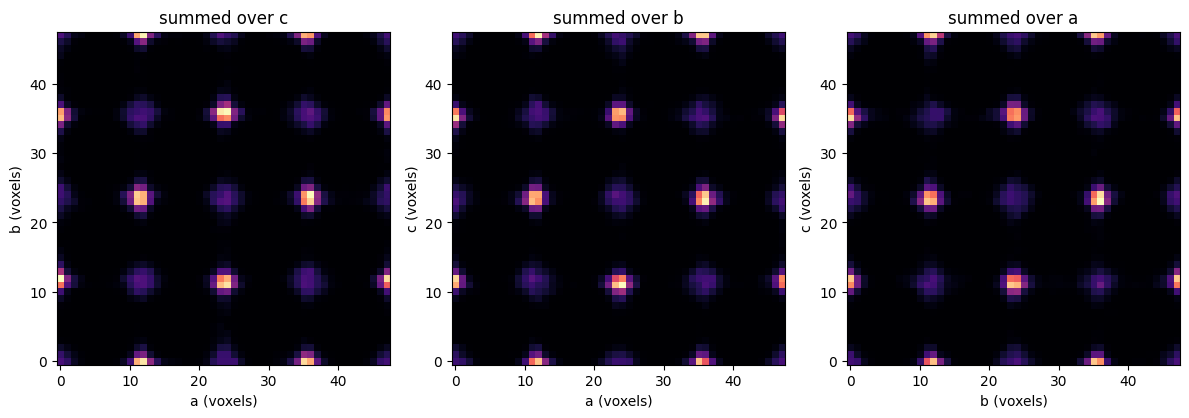

In [4]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

for ax, axis, (xlabel, ylabel) in zip(axes, (2, 1, 0), (('a', 'b'), ('a', 'c'), ('b', 'c'))):
    ax.imshow(vol.data.sum(axis=axis).T, origin='lower', aspect='equal', cmap='magma')
    ax.set_title(f'summed over {"abc"[axis]}')
    ax.set_xlabel(f'{xlabel} (voxels)')
    ax.set_ylabel(f'{ylabel} (voxels)')

fig.tight_layout()

## Finding the sites

We build the [`Crystallizer`][gemdat.crystallizer.Crystallizer] from the **full** trajectory
(so the Sb/W&ndash;S framework is available later) and tell it which species is mobile.
[`Crystallizer.mobile_sites`][gemdat.crystallizer.Crystallizer.mobile_sites] segments the
sodium density into discrete sites with partial occupancies using a watershed algorithm.

How many sites are found is controlled by a few knobs (passed through to
[`Volume.find_peaks`][gemdat.Volume.find_peaks] / the watershed):

- **`background_level`** &mdash; fraction of the peak density used as the segmentation floor.
  This is the main knob: raising it trims weak, spurious basins (and shrinks the basins,
  keeping occupancies well below 1).
- **`resolution`** &mdash; the voxel size set above. Too fine over-segments each site into
  several basins; too coarse merges neighbouring sites.
- **`threshold`** &mdash; the difference-of-Gaussian peak-detection threshold (passed to
  `find_peaks`); raise it to drop faint peaks.

The conventional cell carries 6 sodium positions, so the 2&times;2&times;2 supercell has 48
ideal sodium sites. With `background_level=0.25` the watershed lands exactly on those 48: a
site sitting on a cell face would otherwise be detected twice (once just inside each side of
the boundary), but `find_peaks` merges these periodic-image duplicates so it is reported once.

We also pass the optional `snap_to_lower=True`, which reports a site sitting on a face at the
lower end of the axis (~0) rather than just below 1. It trades a little (sub-voxel) precision
for a consistent representation, so it is off by default.

In [5]:
from gemdat.crystallizer import Crystallizer

background_level = 0.25

cr = Crystallizer.from_trajectory(trajectory, floating_specie='Na', resolution=resolution)

sites = cr.mobile_sites(background_level=background_level, snap_to_lower=True)

# `mobile_sites` labels each site by species *and* occupancy (e.g. 'Na:0.42'),
# which makes every site a distinct label. Relabel to the plain element so the
# occupancy doesn't leak into the site labels (and the plot colours by element).
for site in sites:
    site.label = 'Na'

print(f'found {len(sites)} sodium sites (ideal supercell has 48)')
print(f'max occupancy: {max(s.species.num_atoms for s in sites):.2f}')
sites[:5]

found 48 sodium sites (ideal supercell has 48)
max occupancy: 0.56


[PeriodicSite: Na (Na:0.338) (0.02771, 7.369, 10.79) [0.002976, 0.5104, 0.7455],
 PeriodicSite: Na (Na:0.427) (-0.02242, 10.82, 10.67) [0.0, 0.7494, 0.7371],
 PeriodicSite: Na (Na:0.418) (3.611, 7.244, -1.908e-05) [0.2512, 0.5023, 0.0],
 PeriodicSite: Na (Na:0.438) (3.704, 10.64, -3.147e-05) [0.2581, 0.7373, 0.0],
 PeriodicSite: Na (Na:0.437) (7.196, 10.81, -2.456e-05) [0.5, 0.75, 0.0]]

Overlaying the sites (red) on the sodium density isosurface.

In [6]:
vol.plot_3d(structure=sites)

## Comparison with the expected sites

The workshop reference `structure_1.cif` describes the conventional, cubic *I*-43*m*
Na&#8323;(Sb/W)S&#8324; with the sodium spread over a single (disordered) Wyckoff site.
Expanded to the 2&times;2&times;2 MD supercell it lists 48 ideal sodium positions. Overlaying
them on the density shows how well the simulation reproduces the known sodium sublattice.

In [7]:
from pymatgen.core import Structure

from gemdat.io import read_cif

# Conventional I-43m reference, expanded to the 2x2x2 MD supercell and stripped
# down to the sodium sublattice. Place the sites in the volume's lattice so they
# share its coordinate frame.
reference = read_cif(f'{DATA}/structure_1.cif')
reference.make_supercell((2, 2, 2))
reference.remove_species(['S', 'Sb', 'W'])

expected_sites = Structure(
    lattice=vol.lattice,
    species=[site.species.elements[0] for site in reference],
    coords=[site.frac_coords for site in reference],
)

print(f'reference sodium sites: {len(expected_sites)}')
vol.plot_3d(structure=expected_sites)

reference sodium sites: 48


## A lower-symmetry reference: two Na Wyckoff sites

The cubic reference above lumps all sodium into one disordered site. The lower-symmetry
*P*-42&#8321;*c* description in `structure_2.cif` splits the sodium over **two** distinct
Wyckoff sites, Na1 and Na2. Overlaying its sodium sublattice (coloured by site type) on the
density shows how the two environments line up with the simulated density.

In [8]:
# `Structure` and `read_cif` are already imported above.
reference_2 = read_cif(f'{DATA}/structure_2.cif')
reference_2.make_supercell((2, 2, 2))
reference_2.remove_species(['S', 'Sb'])

expected_sites_2 = Structure(
    lattice=vol.lattice,
    species=[site.species.elements[0] for site in reference_2],
    coords=[site.frac_coords for site in reference_2],
    # Keep the Wyckoff labels ('Na1', 'Na2') so plot_3d colours them distinctly.
    labels=[site.label for site in reference_2],
)

vol.plot_3d(structure=expected_sites_2)

## Crystallize

Finally, [`Crystallizer.crystallize`][gemdat.crystallizer.Crystallizer.crystallize] combines
the mobile sodium sites with the time-averaged Sb/W&ndash;S framework and fits the highest
space group that is consistent with the structure, scanning a range of symmetry tolerances.
The same `background_level` is forwarded to the site segmentation.

In [9]:
result = cr.crystallize(background_level=background_level)

print(f'space group: {result.spacegroup_symbol} (#{result.spacegroup_number})')
print(f'symprec:     {result.symprec} Å')
print(f'sites:       {len(result.structure)}')
result.structure
cr.to_cif('na3sbs4_crystallized.cif', background_level=background_level)

space group: I-43m (#217)
symprec:     0.5 Å
sites:       128


CrystallizerResult(structure=Structure Summary
Lattice
    abc : 14.437000408447362 14.437028448369713 14.475216360134393
 angles : 90.00042679958278 89.99975120783192 90.23769395707704
 volume : 3017.005539785143
      A : 14.43696935 -0.02994628 3.137e-05
      B : -0.02994624 14.43699739 -5.366e-05
      C : 3.129e-05 -5.396e-05 14.47521636
    pbc : True True True
PeriodicSite: Sb (0.01602, 0.0272, 7.217) [0.001113, 0.001888, 0.4986]
PeriodicSite: Sb (0.01191, 7.229, 14.44) [0.001862, 0.5007, 0.9974]
PeriodicSite: Sb (-0.0006092, 7.243, 7.208) [0.0009973, 0.5017, 0.4979]
PeriodicSite: Sb (7.236, -0.004747, 14.46) [0.5012, 0.0007146, 0.9989]
PeriodicSite: Sb (7.216, 14.42, 7.212) [0.5019, 0.9997, 0.4982]
PeriodicSite: Sb (7.223, 7.222, 14.43) [0.5014, 0.5013, 0.9971]
PeriodicSite: Sb (3.578, 3.56, 3.553) [0.2484, 0.2471, 0.2454]
PeriodicSite: Sb (3.673, 3.655, 10.79) [0.2549, 0.2537, 0.7451]
PeriodicSite: Sb (3.643, 10.79, 3.639) [0.2539, 0.7479, 0.2514]
PeriodicSite: Sb (3.56, 10.8

The result can be written straight to a CIF file with the fitted symmetry:

```python
cr.to_cif('na3sbs4_crystallized.cif', background_level=background_level)
```

> **Note.** Even for this thermally noisy, W-doped and site-disordered run, the Crystallizer
> recovers the ideal cubic *I*-43*m* (#217) symmetry of Na&#8323;(Sb/W)S&#8324; &mdash; with
> all 48 sodium positions of the supercell &mdash; but only at a loose symmetry tolerance
> (`symprec = 0.5` &#197;). The density-derived site centroids scatter by a few tenths of an
> &#197;ngstr&ouml;m around the ideal Wyckoff positions, so a tight tolerance would treat
> them as inequivalent and collapse the fit to P1. `crystallize` scans a range of tolerances
> and reports the highest symmetry it can justify from the data.